<a href="https://colab.research.google.com/github/temahm/AiCon/blob/main/TIR_Gemini_MultiAgent_XGBoost_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TIR Multi-Agent Demo in Google Colab — XGBoost Version

This notebook demonstrates a **three-agent socio-technical AI workflow** with a **XGBoost prediction model**:

1. **Model 1 — Prediction Agent (XGBoost)**  
   Learns approval patterns from a synthetic training dataset and predicts approve/deny outcomes.

2. **Model 2 — TIR Interrogator (Gemini)**  
   Questions the prediction, detects proxy-risk concerns, highlights uncertainty, and surfaces missing context.

3. **Model 3 — Governance Agent (Gemini)**  
   Reviews the prediction plus the interrogator's findings and decides whether to **APPROVE, DENY, REVIEW, or ESCALATE**.

## This demo is similar to a realistic enterprise workflow:
- a trained ML model
- explainability with SHAP (SHapley Additive exPlanations)
- a separate interrogation layer
- a separate governance layer

##**Accountable decision systems need interrogation and governance combined with Accurate models.**


## 1) Install dependencies

In [25]:
!pip install -q google-genai matplotlib pandas==2.2.2 scikit-learn xgboost shap


## 2) Gemini setup

This notebook expects your Gemini API key to be stored in **Colab Secrets** as:

`GEMINI_API_KEY`


In [26]:
from google.colab import userdata
from google import genai

API_KEY = userdata.get("GEMINI_API_KEY")
if not API_KEY:
    raise RuntimeError("Please add your Gemini API key to Colab Secrets as GEMINI_API_KEY")

client = genai.Client(api_key=API_KEY)

def pick_generate_content_model(client):
    preferred = [
        "models/gemini-2.5-flash",
        "models/gemini-2.0-flash",
        "models/gemini-1.5-flash",
        "models/gemini-1.5-pro",
    ]

    available = []
    for m in client.models.list():
        name = getattr(m, "name", None)
        methods = getattr(m, "supported_actions", None) or getattr(m, "supported_methods", None)
        methods_str = " ".join(methods) if isinstance(methods, (list, tuple)) else str(methods)
        if name and ("generateContent" in methods_str or "generate_content" in methods_str):
            available.append(name)

    for p in preferred:
        if p in available:
            return p

    return available[0] if available else None

MODEL_NAME = pick_generate_content_model(client)
if not MODEL_NAME:
    raise RuntimeError("No available Gemini model supports generateContent for this API key.")

print("Using model:", MODEL_NAME)

def llm(prompt: str) -> str:
    response = client.models.generate_content(
        model=MODEL_NAME,
        contents=prompt
    )
    return (response.text or "").strip()


Using model: models/gemini-2.5-flash


## 3) Imports


In [27]:
import json
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from xgboost import XGBClassifier
import shap

np.random.seed(42)
pd.set_option("display.max_columns", None)


## 4) Create a synthetic training dataset

We generate a dataset large enough to train a realistic model.

The label is synthetic but intentionally constructed to reflect plausible lending-like patterns:
- stronger credit and income improve approval probability
- high debt and instability reduce it
- location-based risk is included so we can discuss proxy concerns


In [28]:
n_train = 2000
train_df = pd.DataFrame({
    "annual_income_usd": np.random.randint(25000, 150000, size=n_train),
    "credit_score": np.random.randint(540, 830, size=n_train),
    "employment_years": np.random.randint(0, 20, size=n_train),
    "debt_ratio": np.round(np.random.uniform(0.03, 0.80, size=n_train), 2),
    "zip_risk_flag": np.random.choice([0, 1], size=n_train, p=[0.75, 0.25]),
    "income_volatility": np.random.choice([0, 1], size=n_train, p=[0.72, 0.28]),
})

latent = (
    (train_df["annual_income_usd"] >= 70000).astype(int) * 1.6
    + (train_df["credit_score"] >= 690).astype(int) * 2.0
    + (train_df["employment_years"] >= 4).astype(int) * 1.0
    - (train_df["debt_ratio"] >= 0.45).astype(int) * 1.6
    - (train_df["debt_ratio"] >= 0.60).astype(int) * 1.4
    - train_df["zip_risk_flag"] * 0.9
    - train_df["income_volatility"] * 0.8
    + np.random.normal(0, 0.8, size=n_train)
)

train_df["approved"] = (latent > 1.0).astype(int)
train_df.head(50)


,annual_income_usd,credit_score,employment_years,debt_ratio,zip_risk_flag,income_volatility,approved
0,146958,784,3,0.15,0,0,1
1,40795,775,8,0.39,0,0,1
2,25860,724,1,0.46,0,1,0
3,128694,811,18,0.47,0,1,1
4,144879,775,0,0.19,0,1,1
5,135268,778,6,0.60,0,1,1
6,101820,805,16,0.05,1,0,1
7,79886,604,2,0.30,0,0,1
8,31265,716,19,0.63,0,0,0
9,107386,542,19,0.46,0,0,1


## 5) Train the XGBoost model


In [29]:
features = [
    "annual_income_usd",
    "credit_score",
    "employment_years",
    "debt_ratio",
    "zip_risk_flag",
    "income_volatility",
]

X = train_df[features]
y = train_df["approved"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

xgb_model = XGBClassifier(
    n_estimators=120,
    max_depth=4,
    learning_rate=0.08,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)

xgb_model.fit(X_train, y_train)

test_pred = xgb_model.predict(X_test)
test_proba = xgb_model.predict_proba(X_test)[:, 1]

print("Test accuracy:", round(accuracy_score(y_test, test_pred), 3))
print()
print(classification_report(y_test, test_pred))


Test accuracy: 0.9

              precision    recall  f1-score   support

           0       0.90      0.87      0.89       177
           1       0.90      0.92      0.91       223

    accuracy                           0.90       400
   macro avg       0.90      0.90      0.90       400
weighted avg       0.90      0.90      0.90       400



## 6) Creating a small dataset for analysis


In [30]:
n_demo = 50
df = pd.DataFrame({
    "applicant_id": range(1, n_demo + 1),
    "annual_income_usd": np.random.randint(25000, 130000, size=n_demo),
    "credit_score": np.random.randint(540, 810, size=n_demo),
    "employment_years": np.random.randint(0, 15, size=n_demo),
    "debt_ratio": np.round(np.random.uniform(0.05, 0.75, size=n_demo), 2),
    "zip_risk_flag": np.random.choice([0, 1], size=n_demo, p=[0.72, 0.28]),
    "income_volatility": np.random.choice([0, 1], size=n_demo, p=[0.70, 0.30]),
})
df.head(50)


,applicant_id,annual_income_usd,credit_score,employment_years,debt_ratio,zip_risk_flag,income_volatility
0,1,31732,594,13,0.29,1,1
1,2,80097,613,2,0.11,0,0
2,3,28487,668,1,0.39,0,0
3,4,125488,795,12,0.56,1,0
4,5,82702,770,11,0.45,0,0
5,6,119961,676,5,0.19,1,0
6,7,110107,651,5,0.51,0,1
7,8,54075,685,0,0.53,0,1
8,9,96031,572,6,0.70,0,0
9,10,109217,799,11,0.15,0,0


## 7) Model 1 — Prediction Agent (XGBoost)


In [31]:
df["pred_probability"] = xgb_model.predict_proba(df[features])[:, 1]
df["pred_decision"] = np.where(df["pred_probability"] >= 0.50, "APPROVE", "DENY")
df["pred_score"] = np.round((df["pred_probability"] - 0.5) * 2, 3)

df[["applicant_id", "pred_probability", "pred_decision", "pred_score"]].head(50)


,applicant_id,pred_probability,pred_decision,pred_score
0,1,0.225544,DENY,-0.549
1,2,0.786041,APPROVE,0.572
2,3,0.051362,DENY,-0.897
3,4,0.947659,APPROVE,0.895
4,5,0.989871,APPROVE,0.980
5,6,0.713016,APPROVE,0.426
6,7,0.214811,DENY,-0.570
7,8,0.011847,DENY,-0.976
8,9,0.035747,DENY,-0.929
9,10,0.997796,APPROVE,0.996


## 8) Explainability with SHAP (tailored for trees)

Even if the prediction model is explainable, the system may still need interrogation and governance.

Showing how to attribute the model’s predictions to input features.

In [32]:
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(df[features])

mean_abs_shap = np.abs(shap_values).mean(axis=0)
importance_df = pd.DataFrame({
    "feature": features,
    "mean_abs_shap": mean_abs_shap
}).sort_values("mean_abs_shap", ascending=False)

importance_df


,feature,mean_abs_shap
3,debt_ratio,1.722533
1,credit_score,1.520279
0,annual_income_usd,1.193898
2,employment_years,0.716415
4,zip_risk_flag,0.536339
5,income_volatility,0.431845


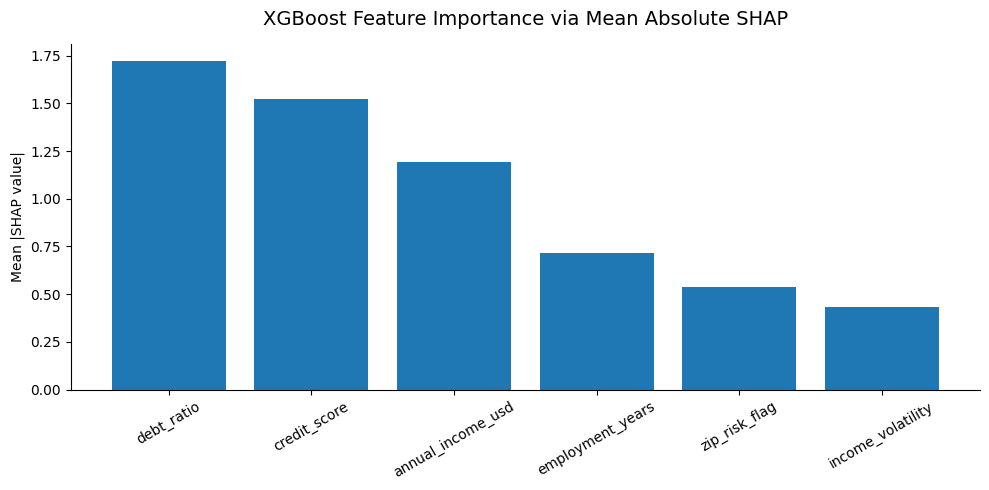

In [33]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(importance_df["feature"], importance_df["mean_abs_shap"])
ax.set_title("XGBoost Feature Importance via Mean Absolute SHAP", fontsize=14, pad=14)
ax.set_ylabel("Mean |SHAP value|")
ax.tick_params(axis="x", rotation=30)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()


## 9) Local explanation for a single case
What influenced the prediction before the TIR agent interrogates it.


In [34]:
case_idx = 29
local_explanation = pd.DataFrame({
    "feature": features,
    "value": df.loc[case_idx, features].values,
    "shap_value": shap_values[case_idx]
}).sort_values("shap_value", ascending=False)

local_explanation


,feature,value,shap_value
1,credit_score,691,1.669443
3,debt_ratio,0.38,1.298909
4,zip_risk_flag,0,0.243292
5,income_volatility,0,0.234080
2,employment_years,1,-1.824049
0,annual_income_usd,31125,-1.922747


## 10) Helper: robust JSON extraction

Making parsing safer in case that Gemini wrapped JSON in code fences.


In [35]:
def extract_json(text):
    text = text.strip()

    if text.startswith("```"):
        text = re.sub(r"^```(?:json)?\s*", "", text)
        text = re.sub(r"\s*```$", "", text)

    start = text.find("{")
    end = text.rfind("}")
    if start == -1 or end == -1:
        raise ValueError("No JSON object found")

    return json.loads(text[start:end+1])


## 11) Model 2 — **TIR Interrogator Agent** (Gemini)

This agent does **not** make the final decision.  
Its role is to:
- interrogate the prediction
- surface proxy risks
- identify missing context
- generate structured questions


In [36]:
def tir_interrogator_agent(row):
    payload = {
        "applicant_id": int(row["applicant_id"]),
        "annual_income_usd": int(row["annual_income_usd"]),
        "credit_score": int(row["credit_score"]),
        "employment_years": int(row["employment_years"]),
        "debt_ratio": float(row["debt_ratio"]),
        "zip_risk_flag": int(row["zip_risk_flag"]),
        "income_volatility": int(row["income_volatility"]),
        "prediction_score": float(row["pred_score"]),
        "prediction_probability": float(row["pred_probability"]),
        "prediction_decision": str(row["pred_decision"]),
    }

    prompt = f'''
You are Model 2 in a multi-agent AI system.
Your role is Interrogative Reasoning.

You do NOT make the final decision.
You question the prediction and surface governance-relevant concerns.

Case:
{json.dumps(payload, indent=2)}

Return STRICT JSON only in this exact schema:
{{
  "questions": ["string", "string"],
  "proxy_risk_detected": true,
  "uncertainty_level": "low",
  "concern_flags": ["string", "string"],
  "interrogation_summary": "string"
}}

Guidelines:
- If zip_risk_flag is 1, assess whether it may be acting as a proxy for social or economic disadvantage.
- If the prediction probability is near 0.50, consider the case borderline.
- Focus on fairness, context, missing information, proxy variables, and premature automation.
- Questions should be concise and serious.
- concern_flags should be short labels like "proxy-risk", "borderline-case", "missing-context", "high-debt-burden".
- Return valid JSON only.
'''

    raw = llm(prompt)
    try:
        return extract_json(raw)
    except Exception:
        return {
            "questions": ["Could this decision be relying on incomplete or proxy-based information?"],
            "proxy_risk_detected": bool(row["zip_risk_flag"] == 1),
            "uncertainty_level": "high",
            "concern_flags": ["parsing-fallback"],
            "interrogation_summary": raw[:500]
        }

sample_interrogation = tir_interrogator_agent(df.iloc[29])
sample_interrogation


{'questions': ['Given the prediction probability of 0.4827, which is extremely close to the decision boundary, what additional contextual information (e.g., details on debt type, career trajectory) would be critical for a more robust decision?',
  "Is the current decision threshold for 'DENY' (e.g., probability < 0.5) appropriate for cases that are so borderline, or should such instances trigger a manual review or a more nuanced assessment?",
  "Could the 'employment_years' of 1 be a proxy for a recent positive career change rather than instability, especially considering income volatility is 0? How is this factor weighted against the good credit score?"],
 'proxy_risk_detected': False,
 'uncertainty_level': 'medium',
 'concern_flags': ['borderline-case',
  'high-debt-burden',
  'missing-context',
  'premature-automation'],
 'interrogation_summary': "The prediction to DENY this applicant is highly borderline, with a probability of 0.4827. While a high debt ratio (0.38) and short employ

## 12) Run Model 2 across the dataset


In [37]:
interrogation_results = df.apply(tir_interrogator_agent, axis=1)

df["tir_questions"] = interrogation_results.apply(lambda x: x["questions"])
df["tir_proxy_risk_detected"] = interrogation_results.apply(lambda x: x["proxy_risk_detected"])
df["tir_uncertainty_level"] = interrogation_results.apply(lambda x: x["uncertainty_level"])
df["tir_concern_flags"] = interrogation_results.apply(lambda x: x["concern_flags"])
df["tir_summary"] = interrogation_results.apply(lambda x: x["interrogation_summary"])

df[[
    "applicant_id",
    "pred_decision",
    "tir_uncertainty_level",
    "tir_proxy_risk_detected",
    "tir_concern_flags",
    "tir_summary"
]].head(50)


,applicant_id,pred_decision,tir_uncertainty_level,tir_proxy_risk_detected,tir_concern_flags,tir_summary
0,1,DENY,low,True,"[proxy-risk, geographic-bias, missing-context,...",The denial is heavily influenced by a low cred...
1,2,APPROVE,low,False,"[low-credit-score, missing-context]","The model's decision to approve, supported by ..."
2,3,DENY,low,False,"[low-income, high-debt-burden, short-employmen...",The strong denial appears to be driven by a co...
3,4,APPROVE,low,True,"[proxy-risk, missing-context, high-debt-burden]",The applicant presents a strong financial prof...
4,5,APPROVE,low,False,"[high-debt-burden, missing-context]",The prediction indicates a very confident 'APP...
5,6,APPROVE,low,True,"[proxy-risk, fairness-audit-needed]",The primary concern for this case is the prese...
6,7,DENY,low,False,"[high-debt-burden, income-volatility-risk, mis...",The prediction to DENY appears primarily drive...
7,8,DENY,low,False,"[missing-context, high-debt-burden, income-ins...",The model's strong DENY decision is heavily in...
8,9,DENY,low,False,"[high-debt-burden, low-credit-score, missing-c...",The prediction to DENY appears strongly driven...
9,10,APPROVE,low,False,"[missing-context, implicit-bias-potential, pre...",The model's prediction for approval is highly ...


## 13) Model 3 — Governance Agent (Gemini)

This agent sees:
- the original case
- the prediction
- the TIR interrogator's findings

It then decides whether to:
- APPROVE
- DENY
- REVIEW
- ESCALATE

This is the layer that converts questioning into **institutional action**. It call the LLM for the cases where defined logic identifies that a deeper analysis is required accoring to defined criteria.


In [45]:
def governance_agent(row):
    prob = float(row["pred_probability"])
    score = float(row["pred_score"])
    uncertainty = str(row["tir_uncertainty_level"]).lower().strip()
    proxy = bool(row["tir_proxy_risk_detected"])
    concerns = row["tir_concern_flags"] if isinstance(row["tir_concern_flags"], list) else []
    concerns = [str(c).lower().strip() for c in concerns]

    serious_flags = {
        "proxy-risk",
        "fairness-risk",
        "institutional-risk",
        "disparate-impact",
        "protected-proxy"
    }

    serious_count = sum(1 for c in concerns if c in serious_flags)
    concern_count = len(concerns)

    # ---------- RULE-FIRST GOVERNANCE ----------
    # Strong, low-risk cases should stay automated.
    if prob >= 0.80 and uncertainty == "low" and not proxy and concern_count == 0:
        final_action = "APPROVE"
        confidence = "high"
    elif prob <= 0.20 and uncertainty == "low" and not proxy and concern_count == 0:
        final_action = "DENY"
        confidence = "high"

    # Borderline cases go to review.
    elif 0.40 <= prob <= 0.60:
        final_action = "REVIEW"
        confidence = "medium"
    elif uncertainty == "medium":
        final_action = "REVIEW"
        confidence = "medium"

    # Escalate only for clearly higher-risk cases.
    elif proxy and uncertainty == "high" and (serious_count >= 1 or concern_count >= 2):
        final_action = "ESCALATE"
        confidence = "medium"
    elif serious_count >= 2:
        final_action = "ESCALATE"
        confidence = "medium"

    # For all other non-borderline cases, preserve the prediction.
    else:
        final_action = str(row["pred_decision"])
        confidence = "medium" if abs(score) < 0.35 else "high"

    requires_human_review = final_action in ["REVIEW", "ESCALATE"]

    # ---------- GEMINI ONLY FOR EXPLANATION ----------
    payload = {
        "case": {
            "applicant_id": int(row["applicant_id"]),
            "annual_income_usd": int(row["annual_income_usd"]),
            "credit_score": int(row["credit_score"]),
            "employment_years": int(row["employment_years"]),
            "debt_ratio": float(row["debt_ratio"]),
            "zip_risk_flag": int(row["zip_risk_flag"]),
            "income_volatility": int(row["income_volatility"]),
        },
        "prediction_agent": {
            "pred_score": score,
            "pred_probability": prob,
            "pred_decision": str(row["pred_decision"]),
        },
        "tir_interrogator": {
            "questions": row["tir_questions"],
            "proxy_risk_detected": proxy,
            "uncertainty_level": uncertainty,
            "concern_flags": concerns,
            "interrogation_summary": str(row["tir_summary"]),
        },
        "governance_decision": {
            "final_action": final_action,
            "confidence": confidence,
            "requires_human_review": requires_human_review
        }
    }

    prompt = f"""
You are writing a short governance explanation for a decision that has already been made.

Decision already chosen:
- final_action: {final_action}
- confidence: {confidence}
- requires_human_review: {requires_human_review}

Inputs:
{json.dumps(payload, indent=2)}

Write 2-4 concise sentences explaining why this governance outcome is appropriate.
Do not change the decision.
Be practical and professional.
"""

    try:
        governance_reasoning = llm(prompt)
    except Exception as e:
        governance_reasoning = f"Rule-based governance decision applied. Explanation unavailable: {str(e)[:200]}"

    return {
        "final_action": final_action,
        "confidence": confidence,
        "governance_reasoning": governance_reasoning,
        "requires_human_review": requires_human_review
    }

sample_governance = governance_agent(df.iloc[29])
sample_governance

{'final_action': 'REVIEW',
 'confidence': 'medium',
 'governance_reasoning': "This case is designated for human review due to the high uncertainty identified by the TIR interrogator. The model's denial is a borderline decision, with a prediction probability very close to the approval threshold. The lack of specific context regarding the applicant's short employment duration, combined with other financial factors, necessitates human assessment to ensure a fair and well-informed outcome.",
 'requires_human_review': True}

## 14) Run Model 3 across the dataset


In [46]:
governance_results = df.apply(governance_agent, axis=1)

df["final_action"] = governance_results.apply(lambda x: x["final_action"])
df["governance_confidence"] = governance_results.apply(lambda x: x["confidence"])
df["governance_reasoning"] = governance_results.apply(lambda x: x["governance_reasoning"])
df["requires_human_review"] = governance_results.apply(lambda x: x["requires_human_review"])

df[[
    "applicant_id",
    "pred_decision",
    "pred_probability",
    "tir_uncertainty_level",
    "final_action",
    "governance_confidence",
    "requires_human_review"
]].head(50)


,applicant_id,pred_decision,pred_probability,tir_uncertainty_level,final_action,governance_confidence,requires_human_review
0,1,DENY,0.225544,low,DENY,high,False
1,2,APPROVE,0.786041,low,APPROVE,high,False
2,3,DENY,0.051362,low,DENY,high,False
3,4,APPROVE,0.947659,low,APPROVE,high,False
4,5,APPROVE,0.989871,low,APPROVE,high,False
5,6,APPROVE,0.713016,low,APPROVE,high,False
6,7,DENY,0.214811,low,DENY,high,False
7,8,DENY,0.011847,low,DENY,high,False
8,9,DENY,0.035747,low,DENY,high,False
9,10,APPROVE,0.997796,low,APPROVE,high,False


## 15) Compare prediction vs final governance output



In [47]:
summary = pd.DataFrame({
    "Prediction Agent": {
        "APPROVE": int((df["pred_decision"] == "APPROVE").sum()),
        "DENY": int((df["pred_decision"] == "DENY").sum()),
        "REVIEW": 0,
        "ESCALATE": 0
    },
    "Final Governance Output": {
        "APPROVE": int((df["final_action"] == "APPROVE").sum()),
        "DENY": int((df["final_action"] == "DENY").sum()),
        "REVIEW": int((df["final_action"] == "REVIEW").sum()),
        "ESCALATE": int((df["final_action"] == "ESCALATE").sum())
    }
}).fillna(0).astype(int)

summary


,Prediction Agent,Final Governance Output
APPROVE,24,18
DENY,26,21
REVIEW,0,10
ESCALATE,0,1


## 16) Data in chart


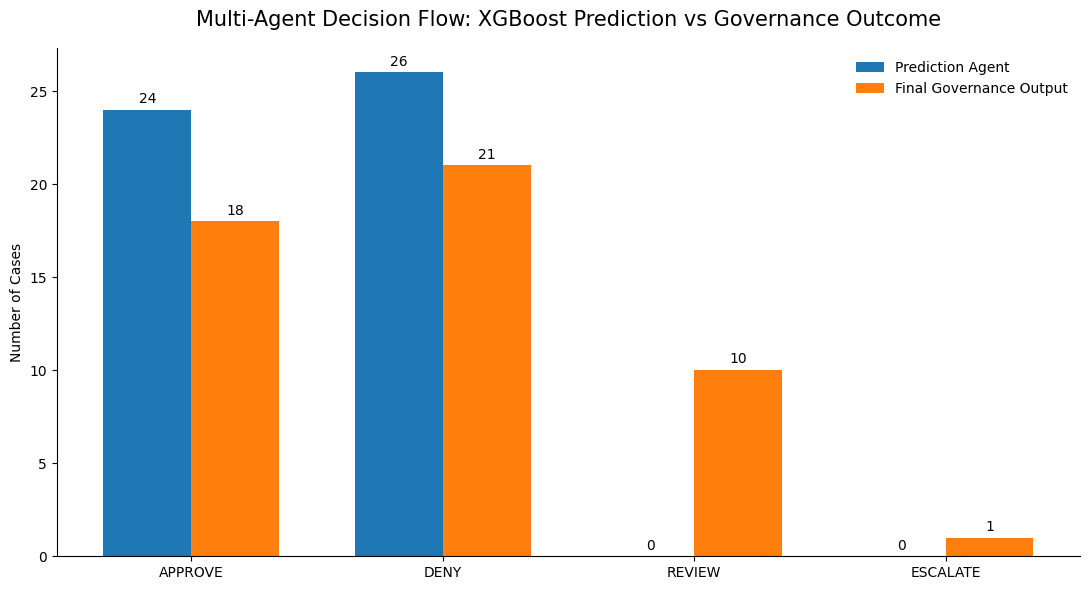

In [48]:
labels = ["APPROVE", "DENY", "REVIEW", "ESCALATE"]
pred_counts = [summary.loc[label, "Prediction Agent"] for label in labels]
gov_counts = [summary.loc[label, "Final Governance Output"] for label in labels]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 6))
ax.bar(x - width/2, pred_counts, width, label="Prediction Agent")
ax.bar(x + width/2, gov_counts, width, label="Final Governance Output")

ax.set_title("Multi-Agent Decision Flow: XGBoost Prediction vs Governance Outcome", fontsize=15, pad=16)
ax.set_ylabel("Number of Cases")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend(frameon=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for i, v in enumerate(pred_counts):
    ax.text(i - width/2, v + 0.2, str(v), ha="center", va="bottom", fontsize=10)
for i, v in enumerate(gov_counts):
    ax.text(i + width/2, v + 0.2, str(v), ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()


## 17) Single-case analysis

Walk through one example end-to-end.


In [49]:
case = df.iloc[29]

print("Applicant ID:", int(case["applicant_id"]))
print("\n--- Model 1: XGBoost Prediction Agent ---")
print("Prediction score:", case["pred_score"])
print("Prediction probability:", round(float(case["pred_probability"]), 3))
print("Prediction decision:", case["pred_decision"])

print("\nTop local SHAP effects for this case:")
display(local_explanation)

print("\n--- Model 2: TIR Interrogator ---")
print("Uncertainty:", case["tir_uncertainty_level"])
print("Proxy risk detected:", case["tir_proxy_risk_detected"])
print("Concern flags:", case["tir_concern_flags"])
print("Questions:")
for q in case["tir_questions"]:
    print("-", q)
print("Summary:", case["tir_summary"])

print("\n--- Model 3: Governance Agent ---")
print("Final action:", case["final_action"])
print("Governance confidence:", case["governance_confidence"])
print("Requires human review:", case["requires_human_review"])
print("Reasoning:", case["governance_reasoning"])


Applicant ID: 30

--- Model 1: XGBoost Prediction Agent ---
Prediction score: -0.035
Prediction probability: 0.483
Prediction decision: DENY

Top local SHAP effects for this case:


,feature,value,shap_value
1,credit_score,691,1.669443
3,debt_ratio,0.38,1.298909
4,zip_risk_flag,0,0.243292
5,income_volatility,0,0.234080
2,employment_years,1,-1.824049
0,annual_income_usd,31125,-1.922747



--- Model 2: TIR Interrogator ---
Uncertainty: high
Proxy risk detected: False
Concern flags: ['borderline-case', 'missing-context', 'employment-duration', 'low-income-threshold']
Questions:
- What specific factors, beyond the credit score, led to the DENY decision despite the prediction probability being very close to the approval threshold?
- Is there additional context regarding the applicant's 1 year of employment (e.g., recent graduation, career change) that could mitigate this factor?
- What is the threshold for income or employment duration that, in combination with a good credit score, tipped this borderline case to a denial?
Summary: The model's denial for applicant 30 is a borderline decision, indicated by a prediction probability (0.48267) very close to the typical 0.50 threshold. Despite a good credit score (691), the low employment duration (1 year) and a relatively modest annual income of $31,125 combined with a 38% debt ratio appear to be significant factors. The lack o

## 18) What this demonstrates

This notebook shows a **multi-agent architecture for Interrogative Reasoning**:

- **Model 1** predicts with a real XGBoost model
- **Model 2** interrogates
- **Model 3** governs

Shows how nterrogation is operationalized as a separate layer that can influence the final outcome.

### Improvement:
Without this architecture, the system produces:
- APPROVE
- DENY

With this architecture, the system also produce:
- REVIEW
- ESCALATE

That is the meaning of **decision-space expansion** in TIR.

### Summary
Even when the prediction model is modern and explainable, the system still needs interrogation and governance to become accountable.
